<a href="https://colab.research.google.com/github/fathinahnj/skripsi/blob/main/waste_classification_skripsi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import

In [1]:
%%capture
!pip install roboflow

In [ ]:
%%capture
!pip install -q inference-gpu
!pip install -q trackers[sort]
!pip install -q supervision==0.27.0

In [4]:
%%capture
!pip install sympy
!pip install torch torchvision

In [2]:
%%capture
!pip install --upgrade ultralytics

In [3]:
%%capture
!pip install deep-sort-realtime
!pip install opencv-python
!pip install numpy

# Dataset

In [5]:
%%capture
from roboflow import Roboflow
rf = Roboflow(api_key="Wi7nmEb34BK9rtJ1O27x")
project = rf.workspace("organic-an-organic").project("river-waste-classification-saya")
version = project.version(5)
dataset = version.download("yolov8")


In [9]:
cp -r /content/River-Waste-Classification-Saya-5/test /content/drive/MyDrive/SKRIPSI

# Load model

In [6]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/SKRIPSI/runs (v3)/runs (v3)/detect/train/weights/best.pt")  # load a custom model

# Train

In [ ]:
# Load a COCO-pretrained YOLOv8n model
model = YOLO("yolov8n.pt")

# Train the model on the COCO8 example dataset for 100 epochs
# results = model.train(data='/content/River-Waste-Classification-Saya-5/data.yaml', epochs=250, imgsz=640)

KeyboardInterrupt: 

# Val

In [ ]:
from ultralytics import YOLO

# Load a model
model = YOLO("yolov8n.pt")  # load an official model
model = YOLO("/content/drive/MyDrive/SKRIPSI/runs (v3)/runs (v3)/detect/train/weights/best.pt")  # load a custom model

# Validate the model
metrics = model.val(data='/content/River-Waste-Classification-Saya-5/data.yaml')  # Specify the correct data.yaml path
metrics.box.map  # map50-95
metrics.box.map50  # map50
metrics.box.map75  # map75
metrics.box.maps  # a list containing mAP50-95 for each category

val: Scanning /content/River-Waste-Classification-Saya-5/valid/labels... 94 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 94/94 1.3Kit/s 0.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.1it/s 5.7s


array([    0.49907,      0.5971])

# Save Model

In [ ]:
#%cp -r '/content/runs (v3.2)' /content/drive/MyDrive/SKRIPSI

In [ ]:
%cd /content/drive/MyDrive/SKRIPSI
%ls

/content/drive/MyDrive/SKRIPSI
 dataset_crop_1to1/         hasil_video2/        'runs (v3)'/
 dataset_crop_1to1_part2/  'null images (raw)'/  'runs (v3.2)'/
'dataset dari wina'/        runs/                'sungai saddang.mp4'
 hasil_video/              'runs (v2)'/          'sungai tallo tol.mp4'


# Predict

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/SKRIPSI/runs (v3)/runs (v3)/detect/train/weights/best.pt")


YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_s

In [ ]:
%%capture
model.predict(
    source="/content/drive/MyDrive/SKRIPSI/hasil_video/DJI_20260217145424_0015_D.MP4",   # video dari drive
    save=True,
    project="/content/drive/MyDrive/SKRIPSI/hasil_video/hasil_video",     # folder output di drive
    conf=0.45,
    stream=False
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/1376) /content/drive/MyDrive/SKRIPSI/hasil_video/DJI_20260217145424_0015_D.MP4: 384x640 1 Non-Plastic, 2 Plastics, 39.8ms
video 1/1 (frame 2/1376) /content/drive/MyDrive/SKRIPSI/hasil_video/DJI_20260217145424_0015_D.MP4: 384x640 1 Non-Plastic, 3 Plastics, 10.6ms
video 1/1 (frame 3/1376) /content/drive/MyDrive/SKRIPSI/hasil_video/DJI_20260217145424_0015_D.MP4: 384x640 2 Non-Plastics, 3 Plastics, 9.6ms
video 1/1 (frame 4/1376) /content/d

# Track Object

In [ ]:
import cv2
import numpy as np
from deep_sort_realtime.deepsort_tracker import DeepSort

In [ ]:
model = YOLO("/content/drive/MyDrive/SKRIPSI/runs (v3)/runs (v3)/detect/train/weights/best.pt")

tracker = DeepSort(
    max_age=30,
    n_init=3,
    max_cosine_distance=0.4
)

In [ ]:
%cd /content/drive/MyDrive/SKRIPSI/hasil_video/hasil_video
%ls

/content/drive/MyDrive/SKRIPSI/hasil_video/hasil_video
 predict/    predict3/  'Recording 2026-02-13 115518.avi'
 predict2/   predict4/


## chatgpt

In [ ]:
cap = cv2.VideoCapture("/predict4/DJI_20260217145424_0015_D.avi")
# cap = cv2.VideoCapture(0)

In [ ]:
while True:
    ret, frame = cap.read()

    if not ret:
        break

    results = model(frame)[0]

    detections = []

    for r in results.boxes.data:
        x1, y1, x2, y2, conf, cls = r

        if conf > 0.5:
            detections.append(
                ([x1, y1, x2-x1, y2-y1], conf, int(cls))
            )

    tracks = tracker.update_tracks(
        detections,
        frame=frame
    )

    for track in tracks:

        if not track.is_confirmed():
            continue

        track_id = track.track_id
        l, t, r, b = track.to_ltrb()

        x1 = int(l)
        y1 = int(t)
        x2 = int(r)
        y2 = int(b)

        cv2.rectangle(frame,(x1,y1),(x2,y2),(0,255,0),2)

        cv2.putText(
            frame,
            f"ID {track_id}",
            (x1,y1-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0,255,0),
            2
        )

    cv2.imshow("Tracking", frame)

    if cv2.waitKey(1) == 27:
        break


In [ ]:
cap.release()
cv2.destroyAllWindows()

In [ ]:
from google.colab.patches import cv2_imshow
import time

while True:

    ret, frame = cap.read()

    if not ret:
        break

    results = model(frame)[0]

    detections = []

    for r in results.boxes.data:
        x1, y1, x2, y2, conf, cls = r

        if conf > 0.5:
            detections.append(
                ([x1, y1, x2-x1, y2-y1], conf, int(cls))
            )

    tracks = tracker.update_tracks(
        detections,
        frame=frame
    )

    for track in tracks:

        if not track.is_confirmed():
            continue

        l, t, r, b = track.to_ltrb()

        cv2.rectangle(frame,
                      (int(l), int(t)),
                      (int(r), int(b)),
                      (0,255,0),2)

    cv2_imshow(frame)
    time.sleep(0.03)

In [ ]:
fourcc = cv2.VideoWriter_fourcc(*'mp4v')

out = cv2.VideoWriter(
    'tracking_output.mp4',
    fourcc,
    30,
    (640, 480)
)

while True:

    ret, frame = cap.read()

    if not ret:
        break

    results = model(frame)[0]

    detections = []

    for r in results.boxes.data:
        x1, y1, x2, y2, conf, cls = r

        if conf > 0.5:
            detections.append(
                ([x1, y1, x2-x1, y2-y1], conf, int(cls))
            )

    tracks = tracker.update_tracks(
        detections,
        frame=frame
    )

    for track in tracks:

        if not track.is_confirmed():
            continue

        l, t, r, b = track.to_ltrb()

        cv2.rectangle(frame,
                      (int(l), int(t)),
                      (int(r), int(b)),
                      (0,255,0),2)

    out.write(frame)

cap.release()
out.release()

## [docs orang](https://colab.research.google.com/github/roboflow-ai/notebooks/blob/main/notebooks/how-to-track-objects-with-deepsort-tracker.ipynb#scrollTo=oEhdLaeaJm1k)

In [ ]:
from inference import get_model
from trackers import DeepSORTFeatureExtractor, DeepSORTTracker

model = YOLO("/content/drive/MyDrive/SKRIPSI/runs (v3)/runs (v3)/detect/train/weights/best.pt")

feature_extractor = DeepSORTFeatureExtractor.from_timm(
    model_name="mobilenetv4_conv_small.e1200_r224_in1k")

tracker = DeepSORTTracker(feature_extractor=feature_extractor)

ModelDependencyMissing: Your `inference` configuration does not support SAM3 model. Install SAM3 dependencies and set CORE_MODEL_SAM3_ENABLED to True.
ModelDependencyMissing: Your `inference` configuration does not support Gaze Detection model. Use pip install 'inference[gaze]' to install missing requirements.To suppress this warning, set CORE_MODEL_GAZE_ENABLED to False.


ImportError: cannot import name 'DeepSORTFeatureExtractor' from 'trackers' (/usr/local/lib/python3.12/dist-packages/trackers/__init__.py)

In [ ]:
CONFIDENCE_THRESHOLD = 0.3
NMS_THRESHOLD = 0.3

SOURCE_VIDEO_PATH = "/content/drive/MyDrive/SKRIPSI/hasil_video/DJI_20260217145424_0015_D.MP4"
TARGET_VIDEO_PATH = "/content/drive/MyDrive/SKRIPSI/hasil_video/tracking"

In [ ]:
import supervision as sv

color = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff8080", "#ff66b2", "#ff66ff", "#b266ff",
    "#9999ff", "#3399ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])

box_annotator = sv.BoxAnnotator(
    color=color,
    color_lookup=sv.ColorLookup.TRACK)

trace_annotator = sv.TraceAnnotator(
    color=color,
    color_lookup=sv.ColorLookup.TRACK,
    thickness=2,
    trace_length=100)

label_annotator = sv.LabelAnnotator(
    color=color,
    color_lookup=sv.ColorLookup.TRACK,
    text_color=sv.Color.BLACK,
    text_scale=0.8)

In [ ]:
frame_samples = []

def callback(frame, i):
    result = model.infer(frame, confidence=CONFIDENCE_THRESHOLD)[0]
    detections = sv.Detections.from_inference(result).with_nms(threshold=NMS_THRESHOLD)
    detections = tracker.update(detections, frame=frame)

    annotated_image = frame.copy()
    annotated_image = box_annotator.annotate(annotated_image, detections)
    annotated_image = trace_annotator.annotate(annotated_image, detections)
    annotated_image = label_annotator.annotate(annotated_image, detections, detections.tracker_id)

    if i % 30 == 0 and i != 0:
        frame_samples.append(annotated_image)

    return annotated_image

# tracker.reset()

In [ ]:
sv.process_video(
    source_path=SOURCE_VIDEO_PATH,
    target_path=TARGET_VIDEO_PATH,
    callback=callback,
    show_progress=True,
)

Processing video:   0%|          | 0/1376 [00:00<?, ?it/s]

KeyboardInterrupt: 

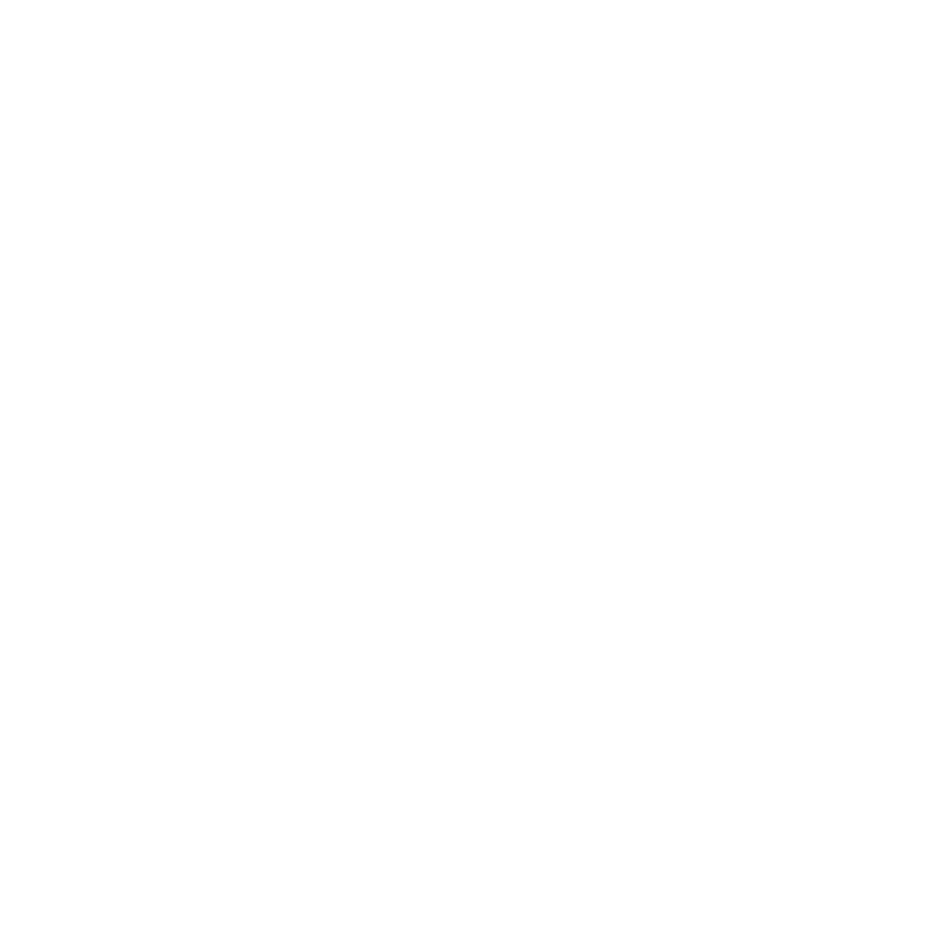

In [ ]:
sv.plot_images_grid(images=frame_samples[:4], grid_size=(2, 2))

## roboflow

https://trackers.roboflow.com/develop/learn/track/#trackers

In [ ]:
trackers track \
    --source SOURCE_VIDEO_PATH \
    --model rfdetr-nano \
    --tracker sort \
    --display \
    --show-confidence \
    --show-labels \
    --output TARGET_VIDEO_PATH

SyntaxError: invalid syntax (8019708.py, line 1)

In [ ]:
import cv2

import supervision as sv
from inference import get_model
from trackers import sort

model = get_model(model)
tracker = sort(
    lost_track_buffer=60,
    minimum_consecutive_frames=5,
)

cap = cv2.VideoCapture(SOURCE_VIDEO_PATH)
while True:
    ret, frame = cap.read()
    if not ret:
        break

    result = model.infer(frame)[0]
    detections = sv.Detections.from_inference(result)
    detections = tracker.update(detections)

ImportError: cannot import name 'sort' from 'trackers' (/usr/local/lib/python3.12/dist-packages/trackers/__init__.py)

In [ ]:
import cv2
from ultralytics import YOLO
from deep_sort_realtime.deepsort_tracker import DeepSort

# load YOLO
model = model

# DeepSORT
tracker = DeepSort(max_age=30)

cap = cv2.VideoCapture("video.mp4")

while True:

    ret, frame = cap.read()

    if not ret:
        break

    results = model(frame)[0]

    detections = []

    for box in results.boxes.data:

        x1, y1, x2, y2, conf, cls = box

        if conf > 0.5:

            detections.append(
                ([x1, y1, x2-x1, y2-y1], conf, int(cls))
            )

    tracks = tracker.update_tracks(
        detections,
        frame=frame
    )

    for track in tracks:

        if not track.is_confirmed():
            continue

        track_id = track.track_id

        l, t, r, b = track.to_ltrb()

        cv2.rectangle(
            frame,
            (int(l), int(t)),
            (int(r), int(b)),
            (0,255,0),
            2
        )

        cv2.putText(
            frame,
            f"ID {track_id}",
            (int(l), int(t)-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0,255,0),
            2
        )

    cv2.imshow("Tracking", frame)

    if cv2.waitKey(1) == 27:
        break

cap.release()
cv2.destroyAllWindows()

# Analisis BB

## Thresholding

In [ ]:
import os
import pandas as pd

dataset_path = "/content/River-Waste-Classification-Saya-5"

data = []

splits = ["train", "valid", "test"]

for split in splits:

    label_folder = os.path.join(dataset_path, split, "labels")

    for label_file in os.listdir(label_folder):

        label_path = os.path.join(label_folder, label_file)

        with open(label_path) as f:
            lines = f.readlines()

        for line in lines:

            cls, xc, yc, bw, bh = map(float, line.split())

            relative_area = bw * bh

            data.append({
                "split": split,
                "class": cls,
                "width_ratio": bw,
                "height_ratio": bh,
                "relative_area": relative_area
            })

df = pd.DataFrame(data)

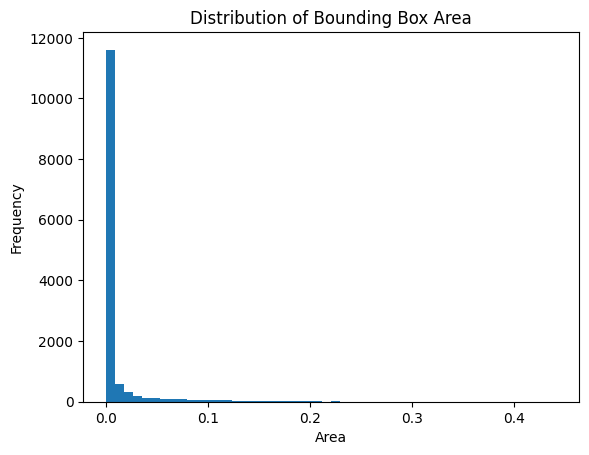

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df["relative_area"], bins=50)

plt.title("Distribution of Bounding Box Area")
plt.xlabel("Area")
plt.ylabel("Frequency")

plt.show()

In [ ]:
df["relative_area"].describe()

,relative_area
count,13722.000000
mean,0.009963
std,0.031167
min,0.000015
25%,0.000293
50%,0.000732
75%,0.002578
max,0.441370


In [ ]:
# membersihkan outlier
Q1 = df['relative_area'].quantile(0.25)
Q3 = df['relative_area'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower:", lower_bound)
print("Upper:", upper_bound)

df_clean = df[
    (df['relative_area'] >= lower_bound) &
    (df['relative_area'] <= upper_bound)
]

# cek jumlah data
print("Before:", len(df))
print("After:", len(df_clean))

Lower: -0.003134765625
Upper: 0.006005859375
Before: 13722
After: 11260


In [ ]:
df_clean['relative_area'].describe()

,relative_area
count,11260.000000
mean,0.000946
std,0.001116
min,0.000015
25%,0.000248
50%,0.000537
75%,0.001162
max,0.006006


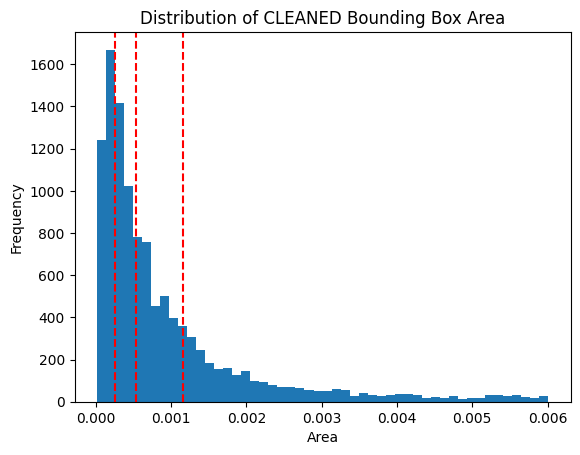

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df_clean["relative_area"], bins=50)

q1 = df_clean["relative_area"].quantile(0.25)
q2 = df_clean["relative_area"].quantile(0.50)
q3 = df_clean["relative_area"].quantile(0.75)

# garis penanda
plt.axvline(q1, linestyle='--', color='red')
plt.axvline(q2, linestyle='--', color='red')
plt.axvline(q3, linestyle='--', color='red')

plt.title("Distribution of CLEANED Bounding Box Area")
plt.xlabel("Area")
plt.ylabel("Frequency")

plt.show()

## Analysis Prep

In [21]:
import os
import pandas as pd
import numpy as np
from ultralytics import YOLO

In [22]:
SMALL_THRESHOLD  = 0.000248
LARGE_THRESHOLD  = 0.001162
# antara keduanya = medium

# resolusi video
IMG_W = 640
IMG_H = 640
IMG_AREA = IMG_W * IMG_H

In [23]:
def categorize_bbox(relative_area):
    if relative_area <= SMALL_THRESHOLD:
        return "small"
    elif relative_area <= LARGE_THRESHOLD:
        return "medium"
    else:
        return "large"

In [24]:
def compute_iou(box1, box2):
    """box format: [x1, y1, x2, y2] dalam piksel."""
    xi1 = max(box1[0], box2[0])
    yi1 = max(box1[1], box2[1])
    xi2 = min(box1[2], box2[2])
    yi2 = min(box1[3], box2[3])
    inter = max(0, xi2 - xi1) * max(0, yi2 - yi1)
    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])
    union = area1 + area2 - inter
    return inter / union if union > 0 else 0

In [25]:
def yolo_normalized_to_xyxy(cx, cy, w, h, img_w, img_h):
    """Konversi YOLO normalized format ke piksel absolut."""
    x1 = (cx - w/2) * img_w
    y1 = (cy - h/2) * img_h
    x2 = (cx + w/2) * img_w
    y2 = (cy + h/2) * img_h
    return [x1, y1, x2, y2]

## Parse GT

In [27]:
dataset_path = "/content/drive/MyDrive/SKRIPSI/runs (v3)"

gt_label_dir = os.path.join(dataset_path, "test", "labels")

In [28]:
gt_by_frame = {}  # key: nama file label, value: list of GT

In [29]:
for label_file in sorted(os.listdir(gt_label_dir)):
    if not label_file.endswith(".txt"):
        continue

    label_path = os.path.join(gt_label_dir, label_file)
    gt_by_frame[label_file] = []

    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls = int(float(parts[0]))
            cx, cy, bw, bh = map(float, parts[1:5])

            relative_area = bw * bh
            xyxy = yolo_normalized_to_xyxy(cx, cy, bw, bh, IMG_W, IMG_H)
            size_cat = categorize_bbox(relative_area)

            gt_by_frame[label_file].append({
                "cls": cls,
                "box": xyxy,
                "relative_area": relative_area,
                "size": size_cat,
                "matched": False  # flag untuk matching nanti
            })

In [30]:
total_gt = sum(len(v) for v in gt_by_frame.values())
print(f"Total GT boxes dari test set: {total_gt}")
print(f"Total frame dengan label: {len(gt_by_frame)}")

Total GT boxes dari test set: 598
Total frame dengan label: 46


## Predict per Frame

In [31]:
# dari test set

test_image_dir = os.path.join(dataset_path, "test", "images")
CONF_THRESHOLD = 0.45
IOU_THRESHOLD  = 0.5

model = YOLO("/content/drive/MyDrive/SKRIPSI/runs (v3)/runs (v3)/detect/train/weights/best.pt")

CLASS_NAMES = {0: "Plastik", 1: "Non-Plastik"}  # sesuaikan dengan data.yaml kamu

In [32]:
# container
all_records = []
fn_records = []

In [34]:
# cari file gambar yang bersesuaian

for label_file, gt_boxes in gt_by_frame.items():
    img_stem = label_file.replace(".txt", "")
    img_path = None
    for ext in [".jpg", ".jpeg", ".png"]:
        candidate = os.path.join(test_image_dir, img_stem + ext)
        if os.path.exists(candidate):
            img_path = candidate
            break

    if img_path is None:
        print(f"[WARNING] Gambar tidak ditemukan untuk: {label_file}")
        continue

    # prediksi
    result = model.predict(source=img_path, conf=CONF_THRESHOLD,
                           verbose=False, save=False)[0]

    # Parse prediction boxes
    pred_boxes = []
    if result.boxes is not None and len(result.boxes) > 0:
        for i in range(len(result.boxes)):
            box_xyxy = result.boxes.xyxy[i].tolist()
            conf_val = result.boxes.conf[i].item()
            cls_val  = int(result.boxes.cls[i].item())
            pred_boxes.append({
                "cls": cls_val,
                "box": box_xyxy,
                "conf": conf_val
            })

    # Sort pred by confidence descending
    pred_boxes.sort(key=lambda x: x["conf"], reverse=True)

    # Reset matched flag untuk frame ini
    for gt in gt_boxes:
        gt["matched"] = False

    # Matching: setiap pred dicoba match ke GT terbaik
    for pred in pred_boxes:
        best_iou  = 0
        best_gt_i = -1

        for i, gt in enumerate(gt_boxes):
            if gt["matched"]:
                continue
            if gt["cls"] != pred["cls"]:
                continue
            iou_val = compute_iou(pred["box"], gt["box"])
            if iou_val > best_iou:
                best_iou  = iou_val
                best_gt_i = i

        if best_iou >= IOU_THRESHOLD and best_gt_i >= 0:
            # TRUE POSITIVE — ukuran dari GT
            gt = gt_boxes[best_gt_i]
            gt["matched"] = True
            all_records.append({
                "frame": label_file,
                "size": gt["size"],
                "cls": gt["cls"],
                "result": "TP",
                "iou": best_iou,
                "conf": pred["conf"]
            })
        else:
            # FALSE POSITIVE — ukuran diestimasi dari prediksi
            bw = pred["box"][2] - pred["box"][0]
            bh = pred["box"][3] - pred["box"][1]
            rel_area = (bw * bh) / IMG_AREA
            pred_size = categorize_bbox(rel_area)
            all_records.append({
                "frame": label_file,
                "size": pred_size,
                "cls": pred["cls"],
                "result": "FP",
                "iou": best_iou,
                "conf": pred["conf"]
            })

    # FALSE NEGATIVES — GT yang tidak terdeteksi sama sekali
    for gt in gt_boxes:
        if not gt["matched"]:
            fn_records.append({
                "frame": label_file,
                "size": gt["size"],
                "cls": gt["cls"],
                "result": "FN",
                "iou": 0,
                "conf": 0
            })

In [35]:
df_results = pd.DataFrame(all_records + fn_records)
print(f"\nTotal records: {len(df_results)}")
print(df_results["result"].value_counts())
print(df_results["size"].value_counts())


Total records: 1360
result
TP    898
FN    298
FP    164
Name: count, dtype: int64
size
medium    536
large     476
small     348
Name: count, dtype: int64


## Metrics

In [36]:
def compute_ap_from_records(tp_flags, fp_flags, n_gt):
    """
    Hitung AP dengan 11-point interpolation.
    tp_flags, fp_flags: list 0/1, sudah diurutkan by confidence desc.
    """
    if n_gt == 0:
        return 0.0, [], []

    tp_cum = np.cumsum(tp_flags)
    fp_cum = np.cumsum(fp_flags)

    recall    = tp_cum / n_gt
    precision = tp_cum / (tp_cum + fp_cum + 1e-10)

    ap = 0
    for thr in np.linspace(0, 1, 11):
        prec_at_rec = precision[recall >= thr]
        ap += np.max(prec_at_rec) if len(prec_at_rec) > 0 else 0
    ap /= 11

    return ap, precision.tolist(), recall.tolist()

In [42]:
summary_rows = []

sizes   = ["small", "medium", "large"]
classes = list(CLASS_NAMES.keys())

In [43]:
for size in sizes:
    df_size = df_results[df_results["size"] == size]
    n_gt_size = len(df_size[df_size["result"].isin(["TP", "FN"])])  # semua GT di kategori ini

    print(f"\n Kategori: {size.upper()}  (Total GT: {n_gt_size})")
    print("-" * 60)

    aps_per_size = []

    for cls in classes:
        cls_name = CLASS_NAMES[cls]

        # Filter per kelas dalam size ini
        df_sc = df_size[df_size["cls"] == cls]
        n_gt_cls = len(df_sc[df_sc["result"].isin(["TP", "FN"])])

        # Ambil hanya TP/FP (bukan FN), sort by confidence desc
        df_det = df_sc[df_sc["result"].isin(["TP", "FP"])].sort_values("conf", ascending=False)

        if len(df_det) == 0 and n_gt_cls == 0:
            print(f"  [{cls_name}] — tidak ada data")
            continue

        tp_flags = (df_det["result"] == "TP").astype(int).values
        fp_flags = (df_det["result"] == "FP").astype(int).values

        ap, precision_curve, recall_curve = compute_ap_from_records(tp_flags, fp_flags, n_gt_cls)

        # Precision & Recall akhir (nilai terakhir di kurva)
        final_prec = precision_curve[-1] if precision_curve else 0.0
        final_rec  = recall_curve[-1]  if recall_curve  else 0.0

        n_tp = int(tp_flags.sum())
        n_fp = int(fp_flags.sum())
        n_fn = n_gt_cls - n_tp

        print(f"  [{cls_name}]")
        print(f"    TP: {n_tp}  |  FP: {n_fp}  |  FN: {n_fn}  |  GT: {n_gt_cls}")
        print(f"    Precision : {final_prec:.4f}")
        print(f"    Recall    : {final_rec:.4f}")
        print(f"    AP@0.5    : {ap:.4f}")

        aps_per_size.append(ap)
        summary_rows.append({
            "size": size,
            "class": cls_name,
            "n_gt": n_gt_cls,
            "TP": n_tp, "FP": n_fp, "FN": n_fn,
            "Precision": round(final_prec, 4),
            "Recall": round(final_rec, 4),
            "AP@0.5": round(ap, 4)
        })

    if aps_per_size:
        map_size = np.mean(aps_per_size)
        print(f"\n  → mAP@0.5 ({size}): {map_size:.4f}")


 Kategori: SMALL  (Total GT: 290)
------------------------------------------------------------
  [Plastik]
    TP: 42  |  FP: 20  |  FN: 74  |  GT: 116
    Precision : 0.6774
    Recall    : 0.3621
    AP@0.5    : 0.3357
  [Non-Plastik]
    TP: 96  |  FP: 38  |  FN: 78  |  GT: 174
    Precision : 0.7164
    Recall    : 0.5517
    AP@0.5    : 0.4953

  → mAP@0.5 (small): 0.4155

 Kategori: MEDIUM  (Total GT: 482)
------------------------------------------------------------
  [Plastik]
    TP: 124  |  FP: 26  |  FN: 42  |  GT: 166
    Precision : 0.8267
    Recall    : 0.7470
    AP@0.5    : 0.6542
  [Non-Plastik]
    TP: 290  |  FP: 28  |  FN: 26  |  GT: 316
    Precision : 0.9119
    Recall    : 0.9177
    AP@0.5    : 0.8931

  → mAP@0.5 (medium): 0.7737

 Kategori: LARGE  (Total GT: 424)
------------------------------------------------------------
  [Plastik]
    TP: 224  |  FP: 44  |  FN: 66  |  GT: 290
    Precision : 0.8358
    Recall    : 0.7724
    AP@0.5    : 0.6892
  [Non-Plas

In [45]:
# Tabel ringkasan
print("\n" + "=" * 70)
print("TABEL RINGKASAN")
print("=" * 70)
df_summary = pd.DataFrame(summary_rows)
print(df_summary.to_string(index=False))

# mAP keseluruhan
overall_map = df_summary["AP@0.5"].mean()
print(f"\nOverall mAP@0.5 (semua ukuran & kelas): {overall_map:.4f}")


TABEL RINGKASAN
  size       class  n_gt  TP  FP  FN  Precision  Recall  AP@0.5
 small     Plastik   116  42  20  74     0.6774  0.3621  0.3357
 small Non-Plastik   174  96  38  78     0.7164  0.5517  0.4953
medium     Plastik   166 124  26  42     0.8267  0.7470  0.6542
medium Non-Plastik   316 290  28  26     0.9119  0.9177  0.8931
 large     Plastik   290 224  44  66     0.8358  0.7724  0.6892
 large Non-Plastik   134 122   8  12     0.9385  0.9104  0.8892

Overall mAP@0.5 (semua ukuran & kelas): 0.6594


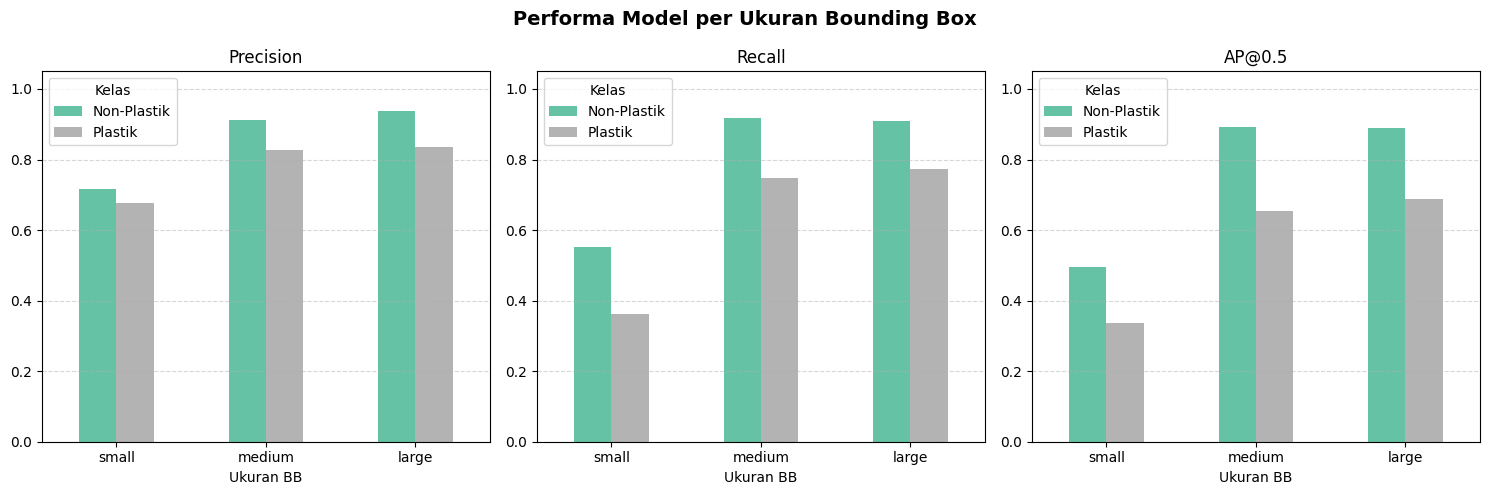

In [46]:
# visualisasi

import matplotlib.pyplot as plt

metrics = ["Precision", "Recall", "AP@0.5"]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    pivot = df_summary.pivot(index="size", columns="class", values=metric)
    pivot = pivot.reindex(["small", "medium", "large"])
    pivot.plot(kind="bar", ax=ax, rot=0, colormap="Set2")
    ax.set_title(metric)
    ax.set_xlabel("Ukuran BB")
    ax.set_ylim(0, 1.05)
    ax.legend(title="Kelas")
    ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.suptitle("Performa Model per Ukuran Bounding Box", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("evaluasi_per_ukuran_bb.png", dpi=150, bbox_inches="tight")
plt.show()